## Supplementary Figure 7

Enviorment: env 1

In [6]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

import sys
sys.path.append("/gpfs/data/shenhavlab/users/ca3261/Visionary-AI-HDP/code/utils/")
from utils import get_test_pr, get_test_roc

In [2]:
dpi = 300
font_size = 12
fig_size = 5
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "DejaVu Sans"

In [12]:
es = [13, 9, 3, 3, 3]
all_data = None
for pw in np.arange(1, 6):
    cases = pd.read_pickle("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/final_pec_20251017.pkl")
    controls = pd.read_pickle(f"/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/data/rev_strat_hc_pw{pw}_controls_20260403.pkl")

    all_ids = cases+controls

    probs_path = f"/gpfs/scratch/ca3261/visionary_ai/full_resnet/resnet_loo/probs/20260723_pw{pw}"
    files = os.listdir(probs_path)

    all_pw_data = []
    finished = []
    for file in files:
        df = pd.read_csv(probs_path + "/" + file)
        all_pw_data.append(df)
        if df["epoch"].max() == 24:
            finished.append(file.split("_")[0])

    array_ids = []
    for id in set(all_ids) - set(finished):
        array_ids.append(str(all_ids.index(id) + 1))
    print("pw", pw, ",".join(array_ids))

    all_pw_data = pd.concat(all_pw_data)
    all_pw_data = all_pw_data[["id", "prob", "label", "epoch"]].groupby(["id", "epoch"]).mean()
    all_pw_data = all_pw_data.reset_index()
    e_pw_data = all_pw_data[all_pw_data["epoch"] == es[pw - 1]].copy()
    if all_data is None:
        e_pw_data["pw_1"] = e_pw_data["prob"]
        all_data = e_pw_data[["id", "label", "pw_1"]]
    else:
        e_pw_data[f"pw_{pw}"] = e_pw_data["prob"]
        all_data = all_data.merge(e_pw_data[["id", "label", f"pw_{pw}"]], how="outer", on=["id", "label"])

pw 1 
pw 2 
pw 3 
pw 4 
pw 5 


In [17]:
sum(all_data["label"]), len(all_data["label"]), sum(all_data["label"] == 0)

(54.0, 1190, 1136)

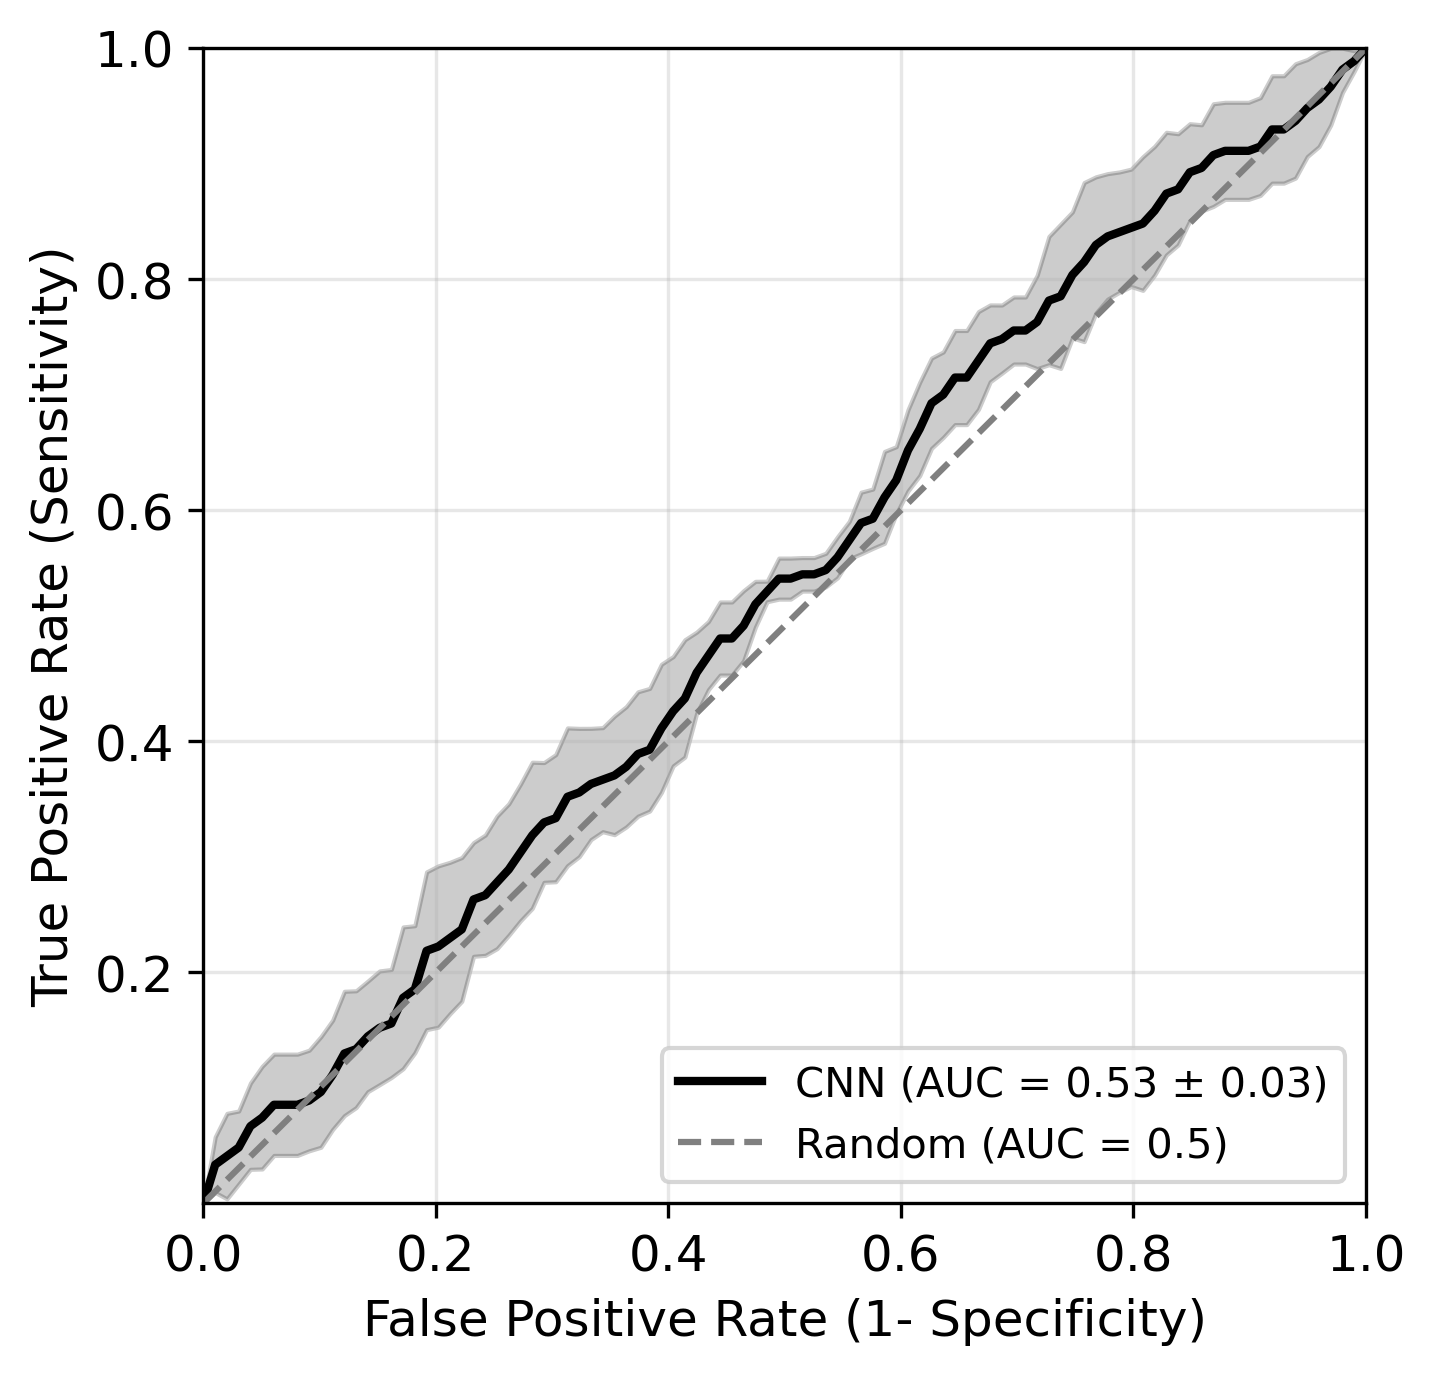

In [ ]:
# ROC
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
reweight = all_data.copy()
plot_avg_roc_from_dicts(reweight, title=f"CNN", add_col=[], pw=5, color="black", rand=True)
plt.title("")
plt.savefig("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/supplementary/fig_7/a_roc.pdf")
plt.show()

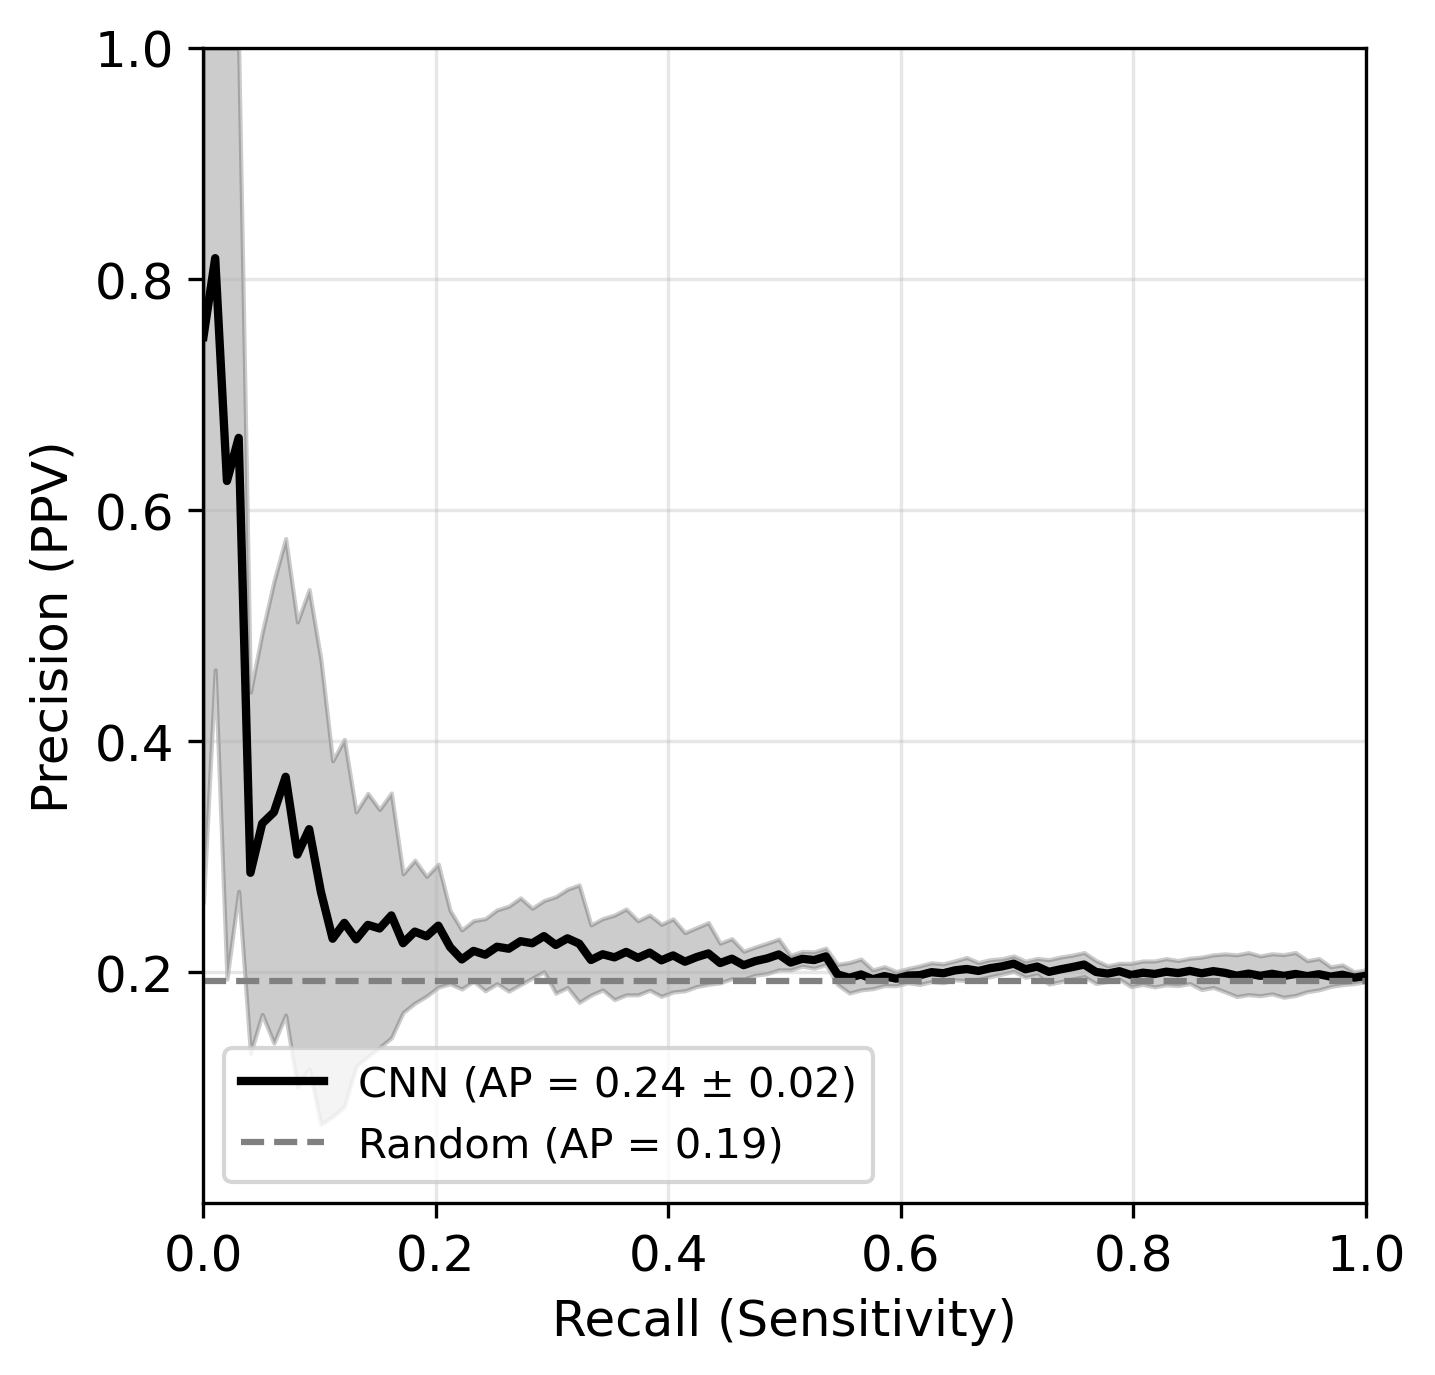

In [ ]:
# PR
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
reweight = all_data.copy()
plot_avg_pr_from_dicts(reweight, title=f"CNN", add_col=[], pw=5, color="black", rand=True)
plt.title("")
plt.savefig("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/supplementary/fig_7/a_pr.pdf")
plt.show()

In [3]:
es = [13, 9, 3, 3, 3]
all_test_data = []
for pw in np.arange(1, 6):
    e = es[pw - 1]
    test_data = pd.read_csv(f"/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_resnet/probs/20260724/pw{pw}/model_epoch_{e}_probs.csv")
    test_data = test_data.groupby("id").mean()
    all_test_data.append(test_data)
all_test_data = pd.concat(all_test_data)
all_test_data = all_test_data.groupby("id").mean()
print(len(all_test_data))

66


In [4]:
cases = pd.read_pickle("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/nyu_paper_cases.pkl")
controls = pd.read_pickle("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/nyu_paper_controls.pkl")
len(cases), len(controls), len(cases + controls),  len(list(set(cases + controls)))

(13, 53, 66, 66)

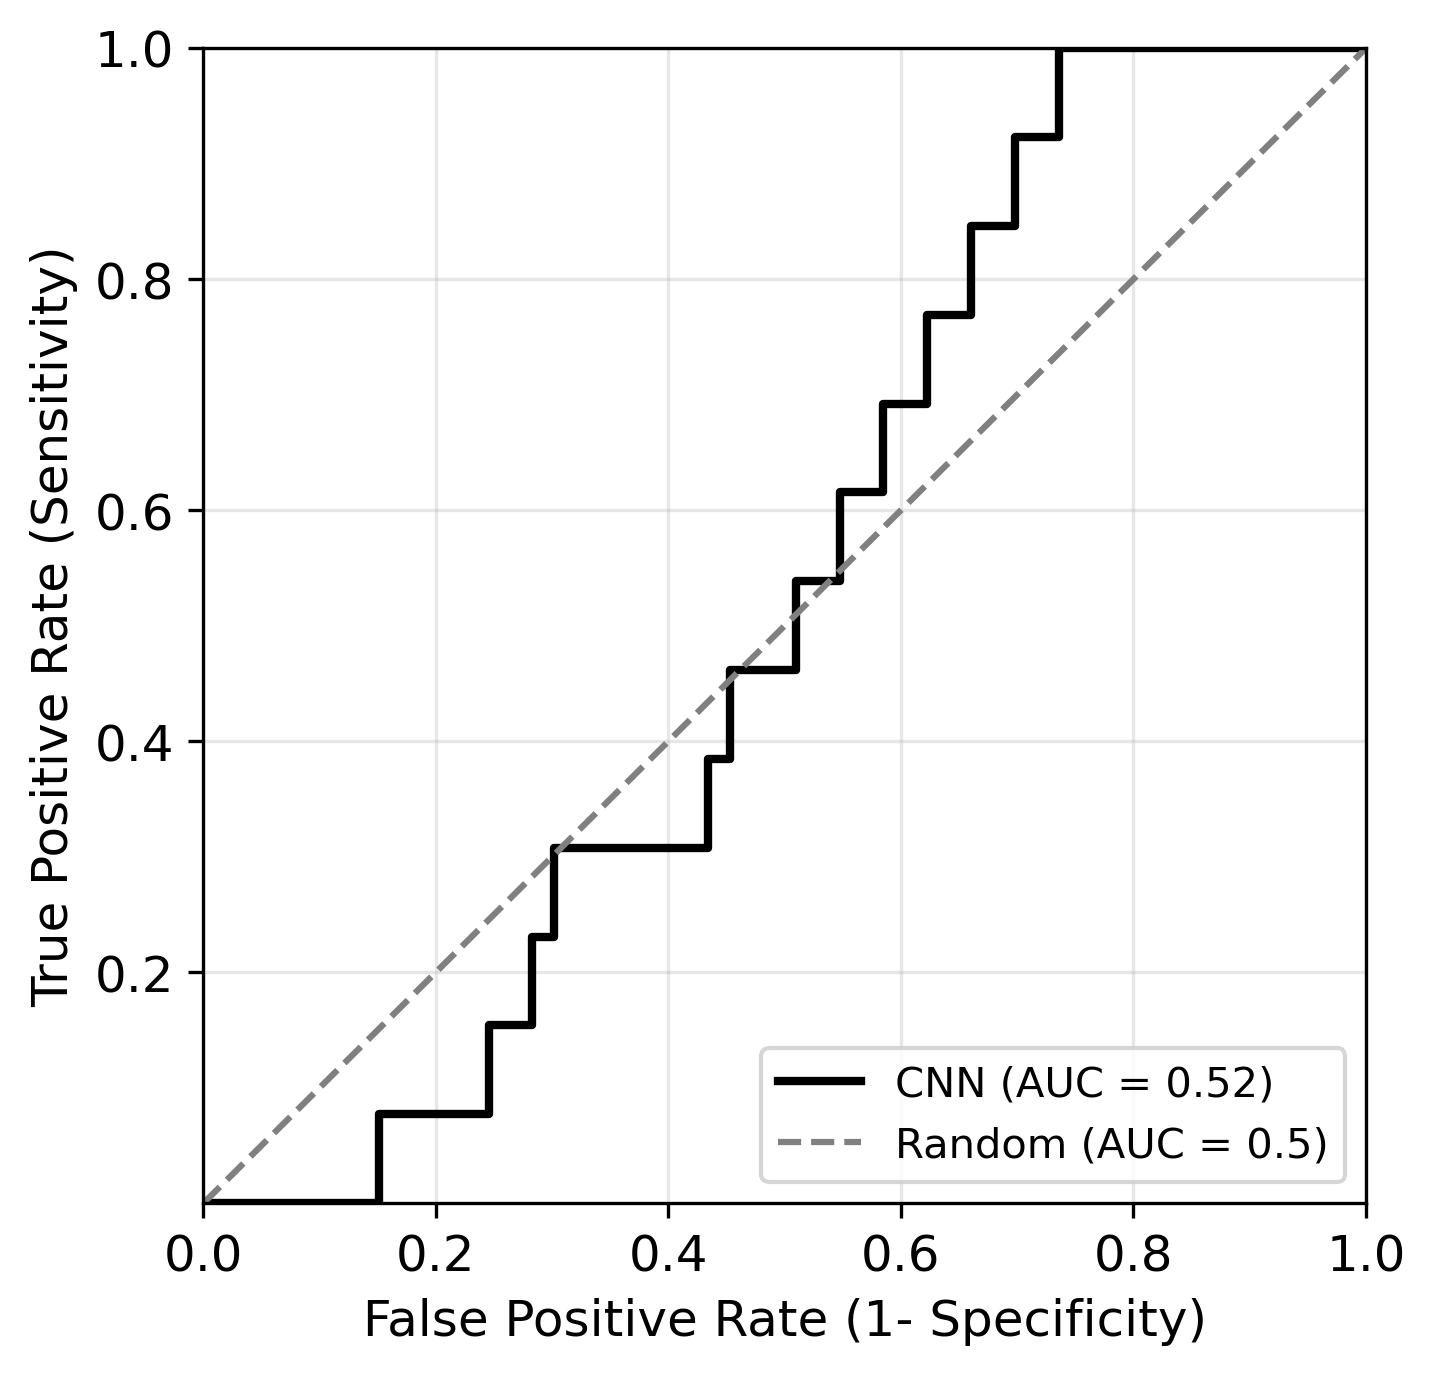

In [5]:
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)

# retinal
get_test_roc(all_test_data["label"], all_test_data["prob"], curve_label="CNN", color="black", rand=True)

plt.savefig("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/supplementary/fig_7/b_roc.pdf")

plt.show()

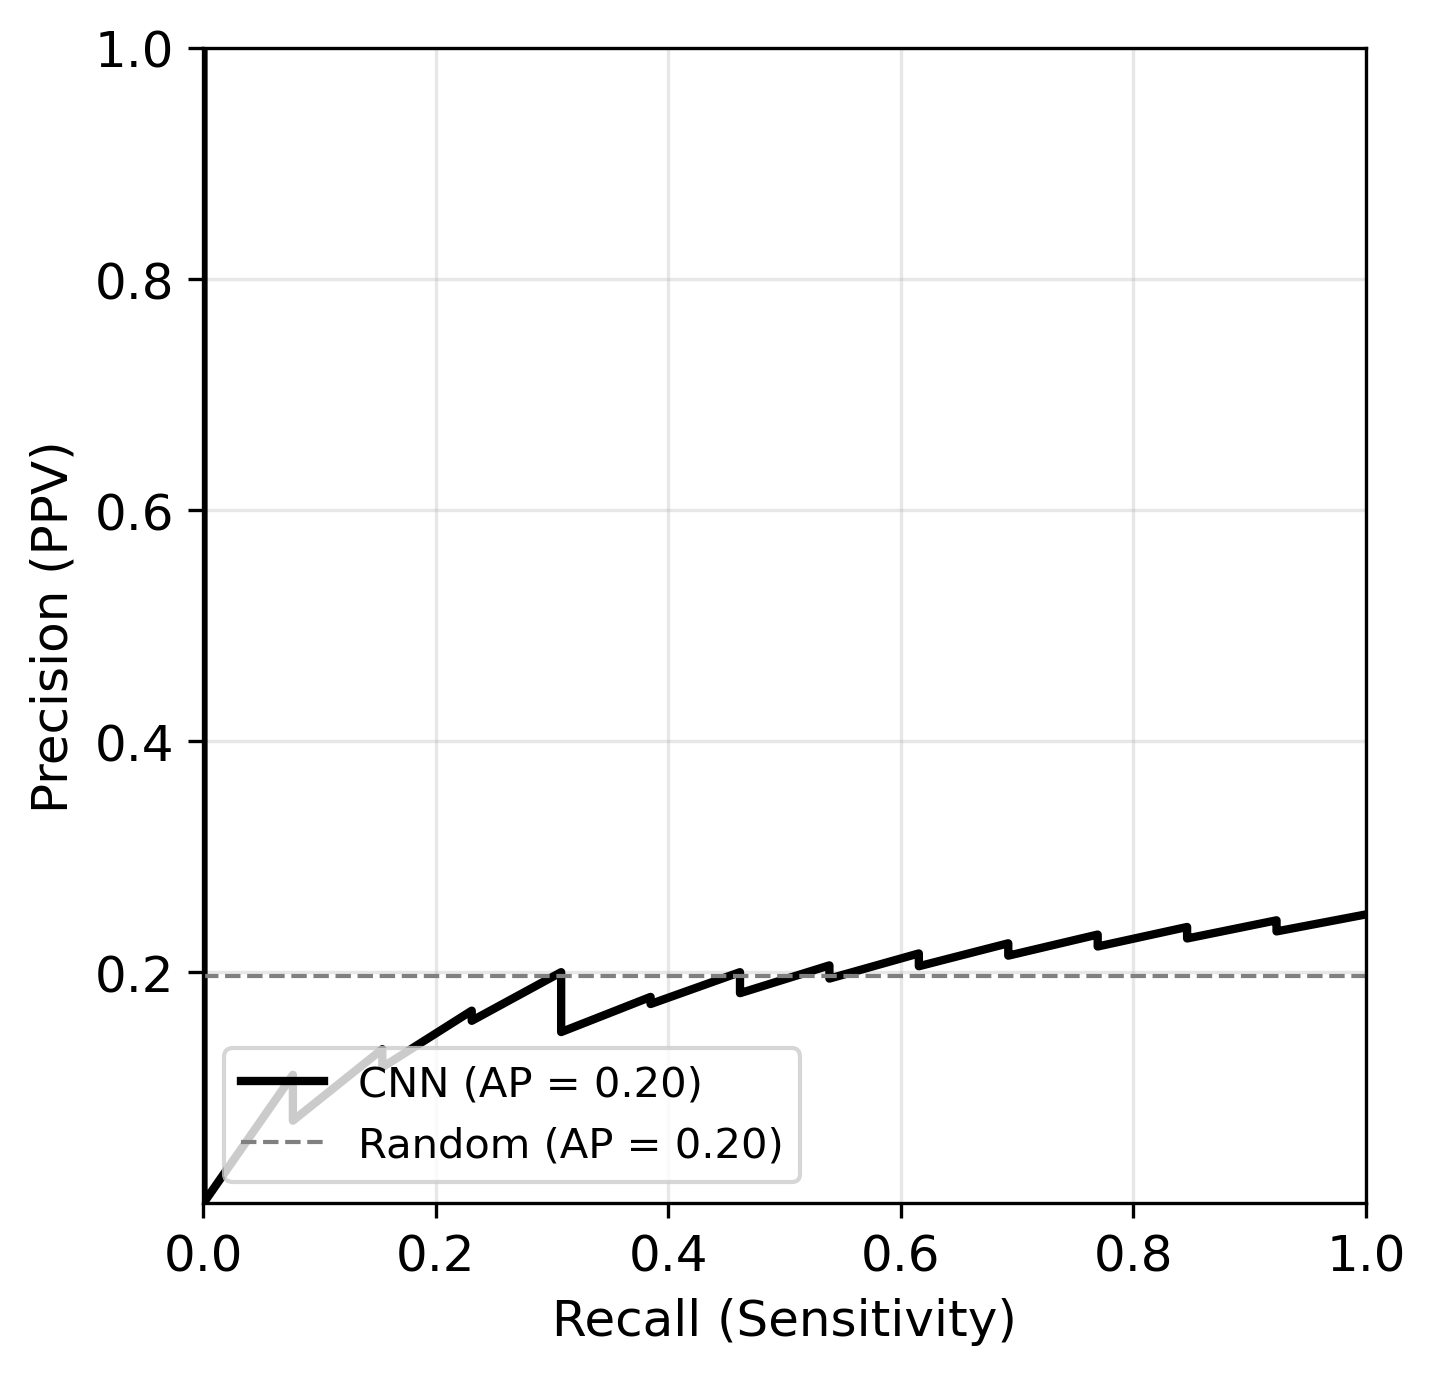

In [6]:
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)

# retinal
get_test_pr(all_test_data["label"], all_test_data["prob"], curve_label="CNN", color="black", rand=True)

plt.savefig("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/supplementary/fig_7/b_pr.pdf")

plt.show()